In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import OrderedDict

In [2]:
mybl_lang = pd.read_csv('mybl_lang.csv')
mybl_lang = mybl_lang.loc[mybl_lang['name'] != 'Swift']
mybl_lang.drop('id', axis=1, inplace=True)

In [3]:
langs = mybl_lang.pivot(index='date_added', columns='name', values=['val', 'val_noexp', 'res_vac'])
langs.dropna(inplace=True)

In [4]:
Mind = pd.MultiIndex.from_tuples([('res', i) for i in langs['val'].columns])
langs_res = langs['res_vac'] * langs['val']
langs_res.columns = Mind
langs = pd.merge(langs, langs_res, how='left', on='date_added')

In [5]:
#normalization
for i in langs.columns:
    langs[i] = langs[i]/(max(langs[i]))

langs.describe()

val                                                        \
                1c         ABAP      Android Data scientist       DevOps   
count  1078.000000  1078.000000  1078.000000    1078.000000  1078.000000   
mean      0.747070     0.433785     0.564210       0.678497     0.639521   
std       0.092519     0.264997     0.224801       0.154989     0.129143   
min       0.562450     0.105000     0.282779       0.413926     0.398362   
25%       0.667548     0.205000     0.365559       0.547872     0.539464   
50%       0.727246     0.322500     0.438369       0.667311     0.586932   
75%       0.829972     0.705000     0.828701       0.822050     0.740506   
max       1.000000     1.000000     1.000000       1.000000     1.000000   

                                                                        ...  \
          Frontend       Golang         Java   Javascript       Python  ...   
count  1078.000000  1078.000000  1078.000000  1078.000000  1078.000000  ...   
mean      0.575208     0.713289     0.575569     0.573668     0.647491  ...   
std       0.222722     0.131877     0.204079     0.220908     0.148722  ...   
min       0.282471     0.474490     0.291237     0.300840     0.407917  ...   
25%       0.389656     0.612245     0.409510     0.383046     0.538296  ...   
50%       0.457875     0.680272     0.468043     0.484142     0.578098  ...   
75%       0.814943     0.807823     0.794257     0.827425     0.766997  ...   
max       1.000000     1.000000     1.000000     1.000000     1.000000  ...   

               res                                                      \
            Golang         Java   Javascript       Python         Ruby   
count  1078.000000  1078.000000  1078.000000  1078.000000  1078.000000   
mean      0.501981     0.740471     0.792649     0.636248     0.819344   
std       0.261272     0.145569     0.125825     0.217787     0.089058   
min       0.166605     0.517099     0.573760     0.310541     0.691845   
25%       0.240215     0.586364     0.664831     0.419887     0.724153   
50%       0.477336     0.784180     0.828808     0.656575     0.828469   
75%       0.741630     0.859302     0.898062     0.837118     0.893494   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                                                                        
             Scala          cpp           cs          iOS          php  
count  1078.000000  1078.000000  1078.000000  1078.000000  1078.000000  
mean      0.783078     0.739502     0.787270     0.725653     0.811191  
std       0.114927     0.126445     0.128981     0.170440     0.084947  
min       0.564208     0.551401     0.583382     0.468127     0.686544  
25%       0.661181     0.619139     0.650625     0.545121     0.721065  
50%       0.814575     0.761094     0.831589     0.771370     0.816086  
75%       0.869821     0.829074     0.887382     0.887190     0.870252  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 64 columns]

([<matplotlib.axis.XTick at 0x1fb9328aad0>,
 [Text(281.0, 0, '2022-01-01'), Text(646.0, 0, '2023-01-01')])

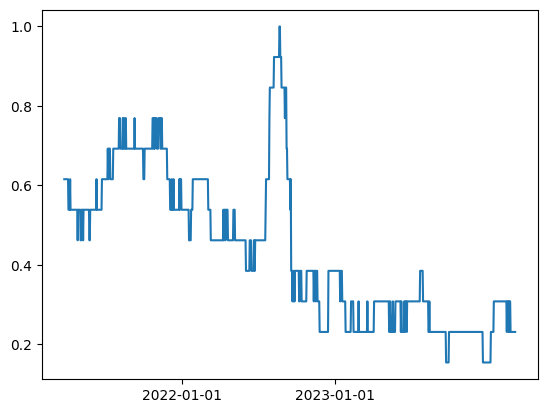

In [6]:
plt.plot(langs["val_noexp", "cpp"])
plt.xticks(['2022-01-01', '2023-01-01'])

In [7]:
def graphs(column, window):
    colmns = langs[column].columns

    langs1 = langs[column].copy()
    langs2 = langs[column].copy()

    fig, ax = plt.subplots()
    fig.set_size_inches(15, 8)
    labels = []
    col = ""

    for i in colmns:
        langs1[i] = langs1[i].rolling(window=window).mean()
        langs2[i] = langs2[i].rolling(window=window).mean()
        langs2[i] = langs2[i].shift(window)

        if col[:2] != 'Py':
            ax.plot(langs1[i] - langs2[i])
            labels.append(langs2[i].name)
            col = i
        else:
            ax.plot(langs1[i] - langs2[i], linestyle='--')
            labels.append(langs2[i].name)
            col = 'Py'

    ax.legend(labels)
    ax.axhline(y=0, color='k')
    plt.xticks('')
    #ax.set_xticklabels((date), rotation=90)

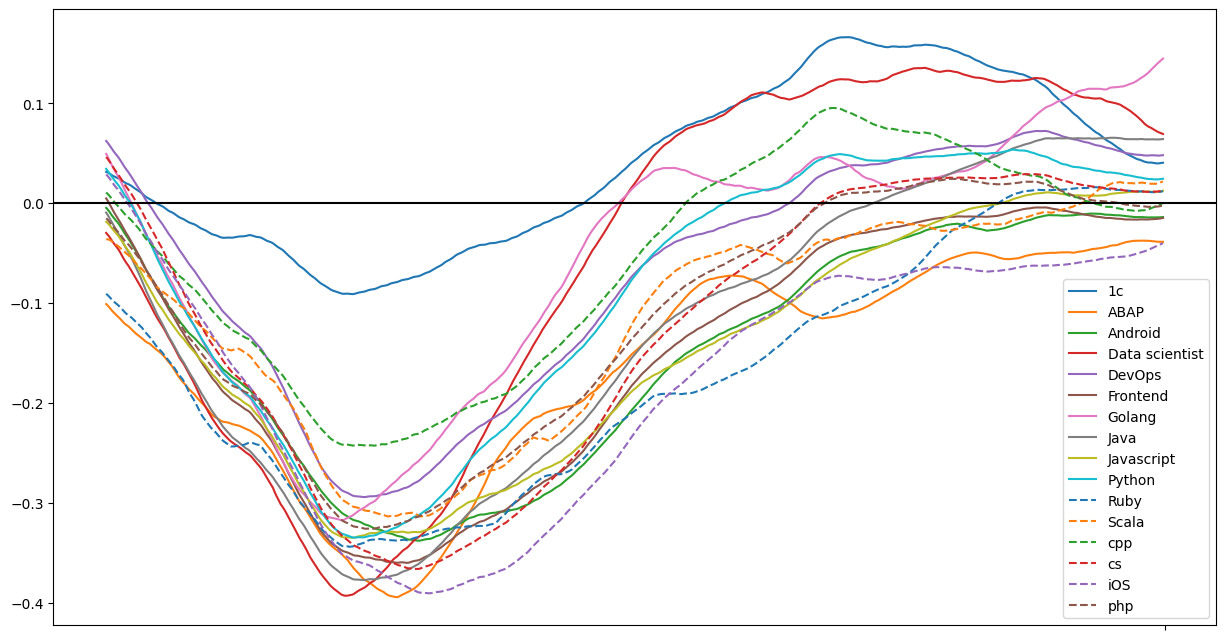

In [8]:
graphs('val', 200)

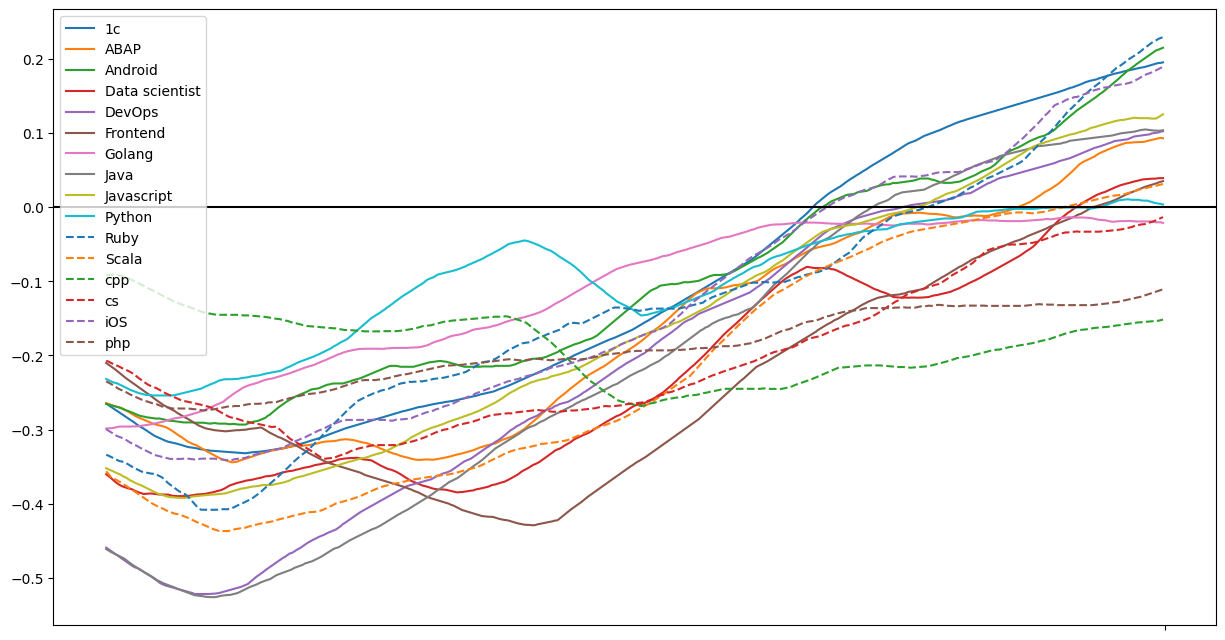

In [9]:
graphs('val_noexp', 300)

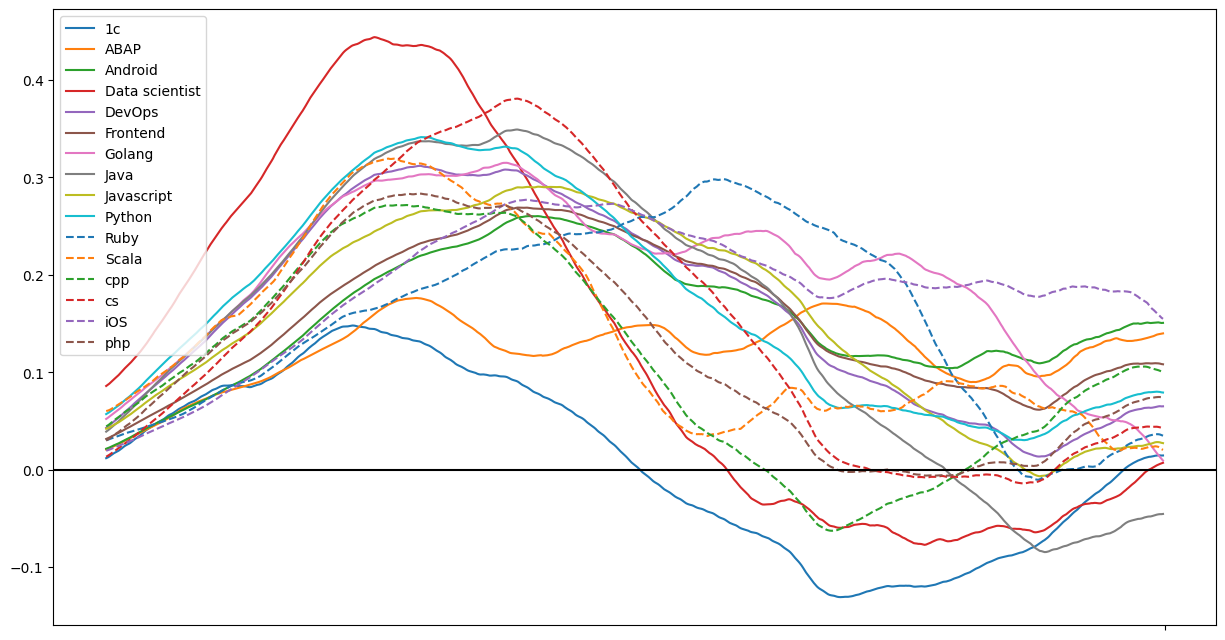

In [10]:
graphs('res_vac', 200)

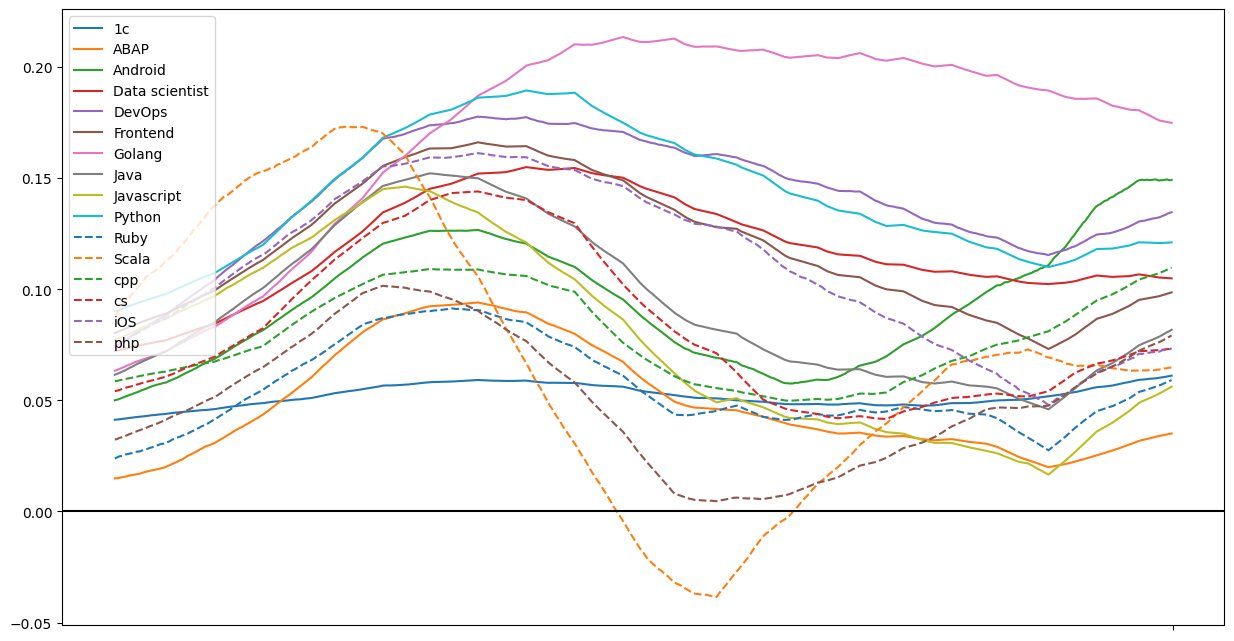

In [11]:
graphs('res', 200)

In [12]:
langs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1078 entries, 2021-03-26 to 2024-03-09
Data columns (total 64 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   (val, 1c)                    1078 non-null   float64
 1   (val, ABAP)                  1078 non-null   float64
 2   (val, Android)               1078 non-null   float64
 3   (val, Data scientist)        1078 non-null   float64
 4   (val, DevOps)                1078 non-null   float64
 5   (val, Frontend)              1078 non-null   float64
 6   (val, Golang)                1078 non-null   float64
 7   (val, Java)                  1078 non-null   float64
 8   (val, Javascript)            1078 non-null   float64
 9   (val, Python)                1078 non-null   float64
 10  (val, Ruby)                  1078 non-null   float64
 11  (val, Scala)                 1078 non-null   float64
 12  (val, cpp)                   1078 non-null   float64
 13  (val, cs

In [13]:
import seaborn as sns

def corr(colmns):
    plt.figure(figsize=(10,10))
    sns.set(font_scale=1.0)
    sns.heatmap(pd.DataFrame(langs[colmns]).corr(),cmap='GnBu',annot=True)

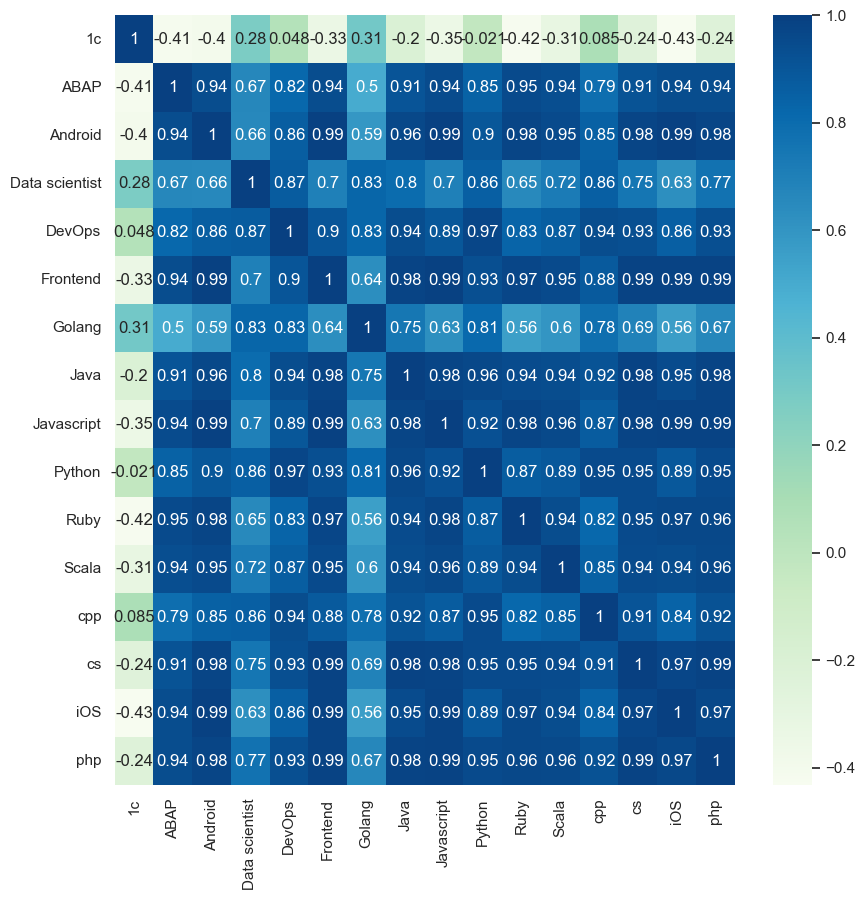

In [14]:
corr('val')

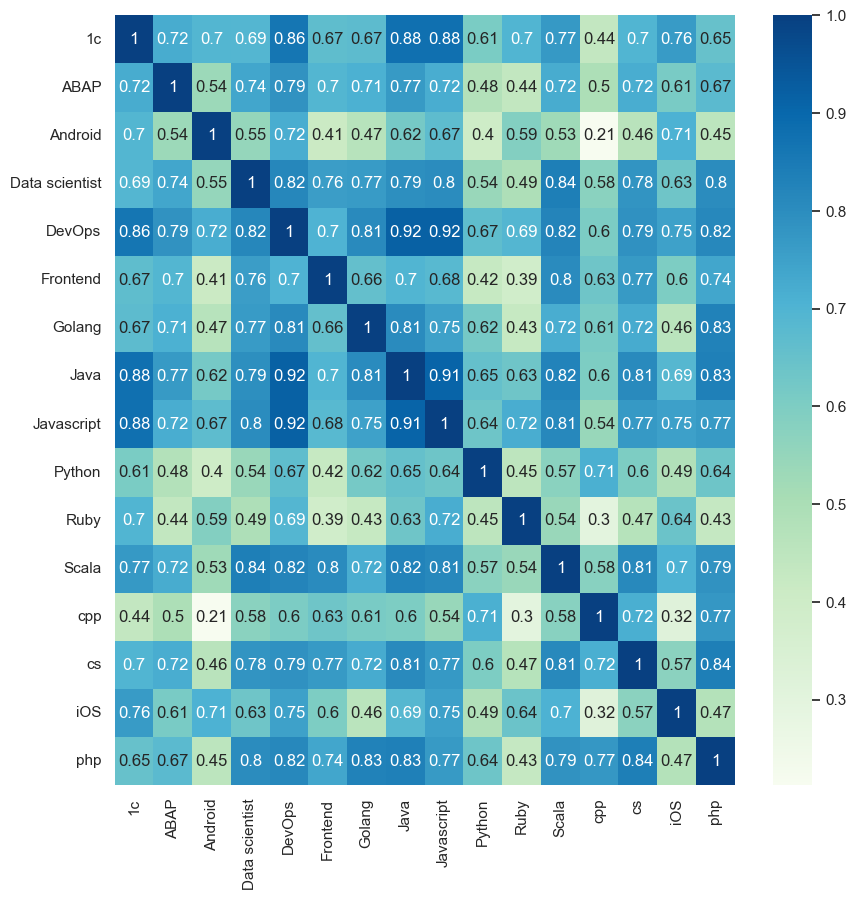

In [15]:
corr('val_noexp')

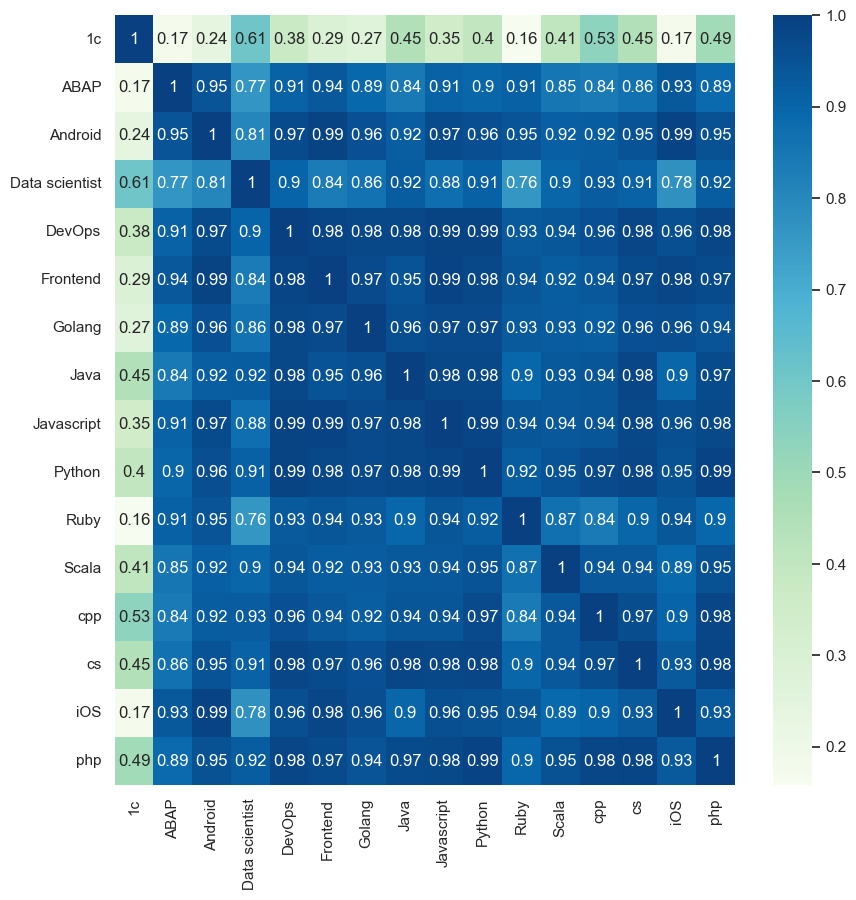

In [16]:
corr('res_vac')

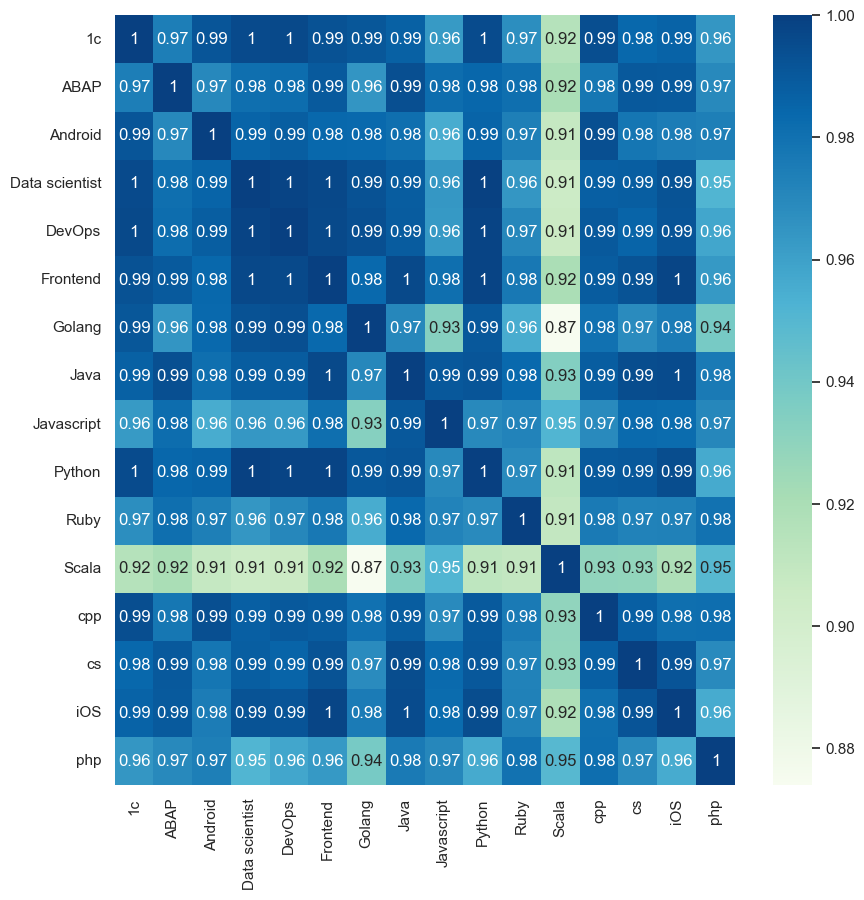

In [17]:
corr('res')

In [18]:
langs

val                                                      \
                  1c   ABAP   Android Data scientist    DevOps  Frontend   
date_added                                                                 
2021-03-26  0.655420  0.825  0.749849       0.854932  0.746091  0.767377   
2021-03-27  0.649917  0.825  0.740785       0.847195  0.736039  0.762696   
2021-03-28  0.638839  0.775  0.726888       0.816248  0.718541  0.752165   
2021-03-29  0.628267  0.760  0.707553       0.800774  0.703276  0.731102   
2021-03-30  0.651003  0.825  0.729909       0.833656  0.721891  0.760122   
...              ...    ...       ...            ...       ...       ...   
2024-03-05  0.942654  0.175  0.347432       0.717602  0.653016  0.388486   
2024-03-06  0.963652  0.175  0.354683       0.731141  0.670886  0.399485   
2024-03-07  0.958729  0.190  0.351057       0.727273  0.674981  0.399485   
2024-03-08  0.952791  0.185  0.353474       0.704062  0.676098  0.401357   
2024-03-09  0.936210  0.175  0.347432       0.692456  0.667908  0.392464   

                                                     ...       res            \
              Golang      Java Javascript    Python  ...    Golang      Java   
date_added                                           ...                       
2021-03-26  0.615646  0.766528   0.841418  0.723322  ...  0.181890  0.524046   
2021-03-27  0.603741  0.757742   0.792910  0.711704  ...  0.178373  0.518040   
2021-03-28  0.595238  0.748078   0.778451  0.706110  ...  0.175861  0.520405   
2021-03-29  0.583333  0.730727   0.750466  0.698795  ...  0.181414  0.517099   
2021-03-30  0.625850  0.750494   0.785914  0.715577  ...  0.175173  0.522086   
...              ...       ...        ...       ...  ...       ...       ...   
2024-03-05  0.903061  0.499231   0.395989  0.577883  ...  0.997012  0.999966   
2024-03-06  0.901361  0.509554   0.419776  0.597246  ...  0.995134  0.996196   
2024-03-07  0.892857  0.512629   0.447295  0.589501  ...  0.999630  0.996059   
2024-03-08  0.880952  0.507138   0.442631  0.586059  ...  1.000000  0.997555   
2024-03-09  0.862245  0.499012   0.434235  0.579604  ...  0.992172  0.999526   

                                                                         \
           Javascript    Python      Ruby     Scala       cpp        cs   
date_added                                                                
2021-03-26   0.575767  0.311512  0.718360  0.607405  0.556537  0.588697   
2021-03-27   0.581329  0.310541  0.718360  0.599765  0.555613  0.586244   
2021-03-28   0.583411  0.312102  0.727273  0.592125  0.551504  0.588866   
2021-03-29   0.574665  0.312829  0.713012  0.595945  0.553594  0.588659   
2021-03-30   0.576200  0.312231  0.711453  0.615046  0.554775  0.587187   
...               ...       ...       ...       ...       ...       ...   
2024-03-05   1.000000  0.998778  0.998663  1.000000  0.995583  0.995083   
2024-03-06   0.998518  0.998400  0.998143  0.987364  0.997453  0.995280   
2024-03-07   0.998389  0.998815  1.000000  1.000000  0.995804  0.997394   
2024-03-08   0.995190  0.999624  0.995989  0.987952  0.997453  0.998436   
2024-03-09   0.997538  0.998469  0.995989  0.987952  0.998233  1.000000   

                                
                 iOS       php  
date_added                      
2021-03-26  0.468127  0.695537  
2021-03-27  0.478127  0.691408  
2021-03-28  0.471392  0.694046  
2021-03-29  0.473969  0.690083  
2021-03-30  0.468867  0.690564  
...              ...       ...  
2024-03-05  0.997487  0.999272  
2024-03-06  0.997487  0.994574  
2024-03-07  1.000000  0.995228  
2024-03-08  1.000000  0.999151  
2024-03-09  0.999923  0.998715  

[1078 rows x 64 columns]